# Monte Carlo Option Pricing Simulator

A Monte Carlo pricer for European options, simulating asset prices under Geometric Brownian Motion. Uses antithetic variates for variance reduction, validates prices against the closed-form Black-Scholes solution, and measures the convergence rate against the number of simulated paths.

## Results

*(to be completed)*

**Parameter choice for the notebook.** The standard benchmark case, chosen so the resulting call price of $10.4506$ can be checked independently against any textbook.

In [1]:
S0, K, T, r, sigma, M = 100.0, 100.0, 1.0, 0.05, 0.2, 500000

## 1. Model and method

$$C_0 = e^{-rT}\mathbb{E}^{\mathbb{Q}}[\text{payoff}(S_T)]$$

<!-- TODO: add derivation link -->

### The model

The asset follows Geometric Brownian Motion under $\mathbb{Q}$:

$$dS_t = r\,S_t\,dt + \sigma S_t\,dW_t,$$

with exact solution

$$S_T = S_0 \exp\!\left(\left(r - \tfrac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\,Z\right), \qquad Z \sim N(0,1).$$

The $-\tfrac{1}{2}\sigma^2$ term is what makes $\mathbb{E}^{\mathbb{Q}}[S_T] = S_0e^{rT}$, as no-arbitrage requires. Because this is the *exact* solution rather than a discretisation, there is no discretisation bias and all residual error is sampling noise.

[derivation](Derivations/02-ST-Formula.pdf)

### One time step is sufficient

Log-returns over disjoint intervals are independent and normally distributed, and sums of independent normals are exactly normal. Splitting $[0,T]$ into $n$ steps gives a terminal log-return with mean $\left(r-\tfrac{1}{2}\sigma^2\right)T$ and variance $\sigma^2 T$ for every $n$.

Since a European payoff depends only on $S_T$, calculating the underlying price for all $t/n \in [0,T]$ is wasted computation. I've included the full path simulations anyway as it is useful for understanding how we are modelling the underlying's movement, and will be required for path-dependent options pricing.

### The Monte Carlo estimator

$$\hat{C}_0 = e^{-rT}\,\frac{1}{M}\sum_{i=1}^{M} \text{payoff}\!\left(S_T^{(i)}\right), \qquad
\mathrm{SE}\!\left(\hat{C}_0\right) = \frac{\hat{\sigma}_D}{\sqrt{M}},$$

where $\hat{\sigma}_D$ is the sample standard deviation of the discounted payoffs $D_i = e^{-rT}\,\text{payoff}\!\left(S_T^{(i)}\right)$. Discounting before taking the standard deviation matters: computing deviations of undiscounted payoffs about a discounted mean gives a biased error estimate.

The estimator is unbiased for every $M$, since $\mathbb{E}[\hat{C}_0] = C_0$ by linearity of expectation.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
from pricer import (call_payoff, put_payoff, simulate_terminal_prices,
                    simulate_paths, mc_european_price, black_scholes_price, straddle_payoff, fit_convergence_rate)
import pandas as pd 

rng = np.random.default_rng(91006)

In [3]:
result = mc_european_price(S0, K, T, r, sigma, M, rng)
lb, ub = result.ci95()
print(f"price: {result.price:.4f}, std_error: {result.std_error:.4f}, ci95: [{lb:.4f}, {ub:.4f}]")

price: 10.4527, std_error: 0.0208, ci95: [10.4119, 10.4935]


### Martingale test
CLT $\Rightarrow \bar{S}_T$ is normally distributed. Standardising $\Rightarrow$ roughly 99.7% of z values should have |z| < 3

In [4]:
ST = simulate_terminal_prices(S0, r, sigma, T, M, rng)
mean = np.mean(ST)
se = np.std(ST, ddof=1)/np.sqrt(M)
target = S0*np.exp(r*T)
z = (mean - target)/se

print(f"mean: {mean:.4f}, target: {target:.4f}, difference: {mean-target:.4f}, |z|: {np.abs(z):.4f}")

mean: 105.1128, target: 105.1271, difference: -0.0143, |z|: 0.4772


**Figure 1.** Two hundred simulated paths under $\mathbb{Q}$ (252 steps, one per trading day), with median $S_0e^{(r-\sigma^2/2)t}$, mean $S_0e^{rt}$ and 2.5%/97.5% quantiles $S_0\exp\!\left((r-\tfrac{1}{2}\sigma^2)t \pm 1.96\,\sigma\sqrt{t}\right)$.

The mean lies above the median, with the gap widening as $e^{\sigma^2t/2}$. The lognormal is right-skewed, so most paths finish below the mean.

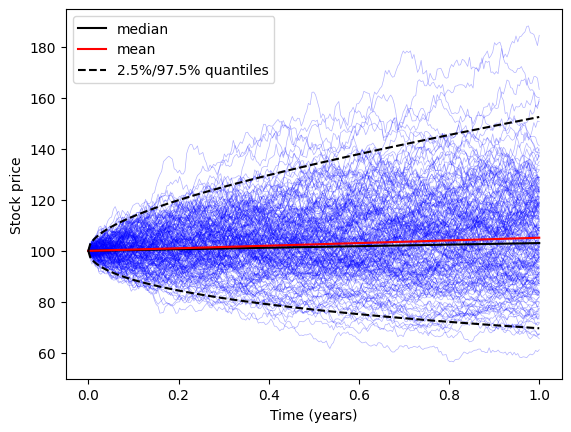

In [5]:
n_steps = 252
n_paths = 200
t = np.linspace(0, T, n_steps+1)

paths = simulate_paths(S0, r, sigma, T, n_steps, n_paths, rng)

median = S0*np.exp((r-0.5*sigma**2)*t)
mean_t = S0*np.exp(r*t)
upper = S0*np.exp((r-0.5*sigma**2)*t + 1.96*sigma*np.sqrt(t))
lower = S0*np.exp((r-0.5*sigma**2)*t - 1.96*sigma*np.sqrt(t))

plt.plot(t, paths, lw=0.5, alpha=0.3, color='blue')
plt.plot(t, median, color='black', label='median')
plt.plot(t, mean_t, color='red', label='mean')
plt.plot(t, upper, color='black', linestyle='--', label='2.5%/97.5% quantiles')
plt.plot(t, lower, color='black', linestyle='--')

plt.xlabel("Time (years)")
plt.ylabel("Stock price")
plt.legend()
plt.show()

**Figure 2.** Distribution of $S_T$ from 200,000 simulated paths against the exact lognormal density with scale $S_0e^{(r-\sigma^2/2)T}$ and shape $\sigma\sqrt{T}$.

Agreement here is a precondition for everything that follows: if the terminal law is wrong, no amount of sampling fixes the prices computed from it.

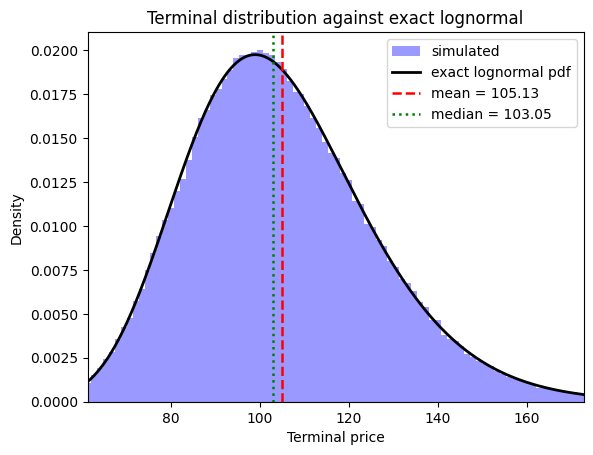

In [6]:
M_hist = 200000
S_T = simulate_terminal_prices(S0, r, sigma, T, M_hist, rng)

mean_T = S0*np.exp(r*T)
median_T = S0*np.exp((r-0.5*sigma**2)*T)
x_min, x_max = np.percentile(S_T, [0.5, 99.5])

grid = np.linspace(x_min, x_max, 500)
pdf = lognorm.pdf(grid, s=sigma*np.sqrt(T), scale=S0*np.exp((r-0.5*sigma**2)*T))

plt.hist(S_T, bins=150, density=True, color="blue", alpha=0.4, label="simulated")
plt.plot(grid, pdf, color="black", lw=2, label="exact lognormal pdf")
plt.axvline(mean_T, color="red", linestyle="--", lw=1.8, label=f"mean = {mean_T:.2f}")
plt.axvline(median_T, color="green", linestyle=":", lw=1.8, label=f"median = {median_T:.2f}")

plt.xlim(x_min, x_max)
plt.xlabel("Terminal price")
plt.ylabel("Density")
plt.title("Terminal distribution against exact lognormal")
plt.legend()
plt.show()

## 2. Validation against the closed form

Under the same model, the European call has an exact solution:

$$C_0 = S_0\,\Phi(d_1) - Ke^{-rT}\,\Phi(d_2),$$

$$d_1 = \frac{\log(S_0/K) + \left(r + \tfrac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T},$$

The corresponding put is

$$P_0 = Ke^{-rT}\,\Phi(-d_2) - S_0\,\Phi(-d_1).$$

The two terms have a direct reading. $\Phi(d_2)$ is the risk-neutral probability that the option finishes in the money, so $Ke^{-rT}\Phi(d_2)$ is the discounted strike weighted by the chance of paying it. $\Phi(d_1)$ is the option's delta, so $S_0\Phi(d_1)$ is the value of the shares held in the replicating portfolio. The formula is therefore the cost of that portfolio: hold $\Phi(d_1)$ shares, borrow $Ke^{-rT}\Phi(d_2)$.

This is not a different model. It evaluates the same expectation $e^{-rT}\mathbb{E}^{\mathbb{Q}}[\text{payoff}(S_T)]$ exactly rather than by sampling, which is what makes it a valid benchmark1.


In [14]:
print(f"Call: {black_scholes_price(S0, K, T, r, sigma, 'call'):.6f}")
print(f"Put:  {black_scholes_price(S0, K, T, r, sigma, 'put'):.6f}")
 

Call: 10.450584
Put:  5.573526


### Measuring the error

Discrepancies are reported in units of the estimator's own standard error:

$$z = \frac{\hat{C}_0 - C_0^{\mathrm{BS}}}{\mathrm{SE}\!\left(\hat{C}_0\right)}.$$

If the implementation is correct, $z$ is a standard normal draw, so $|z| < 2$ is unremarkable and $|z| > 4$ indicates a bug rather than bad luck.

Currency errors are not comparable across strikes: a discrepancy of $0.05$ is $0.2\%$ of a deep in-the-money price and $6\%$ of a far out-of-the-money one. Standardising makes the quantity dimensionless, and the test automatically tightens as $M$ increases.

In [8]:
K_vals = np.arange(70.0, 136.0, 5.0)

exact_values = black_scholes_price(S0, K_vals, T, r, sigma, "call")   # vectorises over K

results = [mc_european_price(S0, k, T, r, sigma, 200_000, rng, "call") for k in K_vals]
prices = np.array([res.price for res in results])
SEs = np.array([res.std_error for res in results])

z_scores = (prices - exact_values)/SEs

print(f"fraction |z| < 1.96 : {np.mean(np.abs(z_scores) < 1.96):.3f}")
print(f"max |z|             : {np.abs(z_scores).max():.3f}")
print(f"mean z              : {np.mean(z_scores):+.3f}   (a systematic offset would appear here)")

fraction |z| < 1.96 : 0.857
max |z|             : 2.361
mean z              : +0.129   (a systematic offset would appear here)


**Figure 3.** Monte Carlo prices against the closed form across strikes, with residuals below in standard-error units. The shaded band is $\pm 1.96$.

Error bars in the upper panel are smaller than the markers at $M = 200{,}000$ — the lower panel is where the discrepancies become legible. Residuals scatter either side of zero with no trend in strike, which is the signature of an unbiased estimator; a systematic tilt with moneyness would indicate bias.

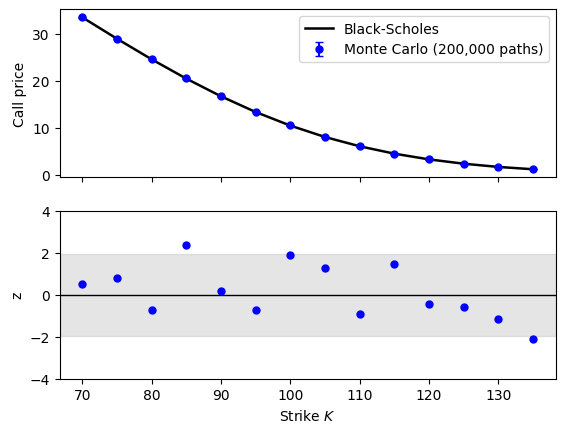

In [20]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True,)

ax1.plot(K_vals, exact_values, color="black", lw=1.8, label="Black-Scholes")
ax1.errorbar(K_vals, prices, yerr=1.96*SEs, fmt="o", ms=5, color="blue",
             capsize=3, label="Monte Carlo (200,000 paths)")
ax1.set_ylabel("Call price")
ax1.legend()

ax2.axhspan(-1.96, 1.96, alpha=0.2, color="grey")
ax2.axhline(0, color="black", lw=1)
ax2.plot(K_vals, z_scores, "o", ms=5, color="blue")
ax2.set_ylim(-4, 4)
ax2.set_xlabel("Strike $K$")
ax2.set_ylabel("z")
plt.show()

### Independent cross-check

Agreement with a closed form validates the simulator but not the formula itself — a typo in $d_1$ would go undetected, since the Monte Carlo estimate would simply be compared against the wrong benchmark.

A binomial lattice priced by backward induction shares no code and no logic with either method. Three-way agreement is therefore substantially stronger evidence than any pairwise comparison.

In [21]:
bs = black_scholes_price(S0, K, T, r, sigma)

mc1 = mc_european_price(S0, K, T, r, sigma, 1_000_000, np.random.default_rng(2024))

print(f"Black-Scholes : {bs:.5f}")

print(f"Monte Carlo   : {mc1.price:.5f} +/- {mc1.std_error:.5f}"
      f"   ({(mc1.price - bs)/mc1.std_error:+.2f} SE)")

Black-Scholes : 10.45058
Monte Carlo   : 10.46750 +/- 0.01474   (+1.15 SE)


**Validation summary.** Simulated prices match the closed form across strikes from 70 to 135, with residuals distributed as expected in standard-error units and no trend in moneyness. Put-call parity holds to machine precision on shared draws, and an independent binomial implementation agrees to three decimal places.

## 3. Convergence rate

Section 2 established that the estimator is correct. This section measures how fast it converges, and confirms that the error it reports matches the error it actually makes.

### The predicted rate

For an unbiased estimator, mean squared error decomposes as

$$\mathrm{RMSE}^2 = \underbrace{\left(\mathbb{E}[\hat{C}_0] - C_0\right)^2}_{\text{bias}^2} + \underbrace{\mathrm{Var}\!\left(\hat{C}_0\right)}_{\text{variance}},$$

and with zero bias the RMSE is simply the standard deviation of the estimator:

$$\mathrm{RMSE}(M) = \frac{\sigma_D}{\sqrt{M}} = \sigma_D\,M^{-1/2}.$$

Taking logs turns this into a straight line,

$$\log \mathrm{RMSE} = \log \sigma_D - \tfrac{1}{2}\log M,$$

so a log-log plot should have slope $-\tfrac{1}{2}$, and its intercept should recover $\sigma_D$ — the standard deviation of the discounted payoffs. Fitting both turns "it converges" into two testable numbers.

This is a slow rate: quadrupling the number of paths halves the error, so one extra decimal place costs $100\times$ the computation. Its redeeming feature is that the exponent does not depend on dimension, which is why Monte Carlo is preferred to quadrature for high-dimensional payoffs.

### Why the experiment must be repeated

A single run produces one error, which is one draw from a distribution — it may be small by luck. Fitting a slope through single-run errors is unreliable for that reason.

Instead the entire pricing experiment is repeated $R$ times at each path count, and the empirical RMSE measured against the known Black-Scholes value. With $R = 200$, the RMSE estimate itself carries roughly $1/\sqrt{2R} \approx 5\%$ relative noise, which is small enough for the fitted slope to be meaningful.

In [25]:
path_counts = np.array([500, 2000, 8000, 32000, 128000, 512000])
n_reps = 200

study = convergence_study(S0, K, T, r, sigma, path_counts, n_reps, rng)

slope, const = fit_convergence_rate(study["n_paths"], study["RMSE"])
print(f"fitted slope     : {slope:+.4f}   (theory -0.5)")
print(f"fitted constant  : {const:.3f}   (should recover sigma_D)")

fitted slope     : -0.5031   (theory -0.5)
fitted constant  : 14.816   (should recover sigma_D)


In [ ]:
D = np.exp(-r*T)*call_payoff(
        simulate_terminal_prices(S0, r, sigma, T, 1_000_000, rng), K)
print(f"sigma_D measured directly : {D.std(ddof=1):.3f}")

sigma_D measured directly : 14.726


### Bias or variance?

The two sources of error behave completely differently as $M$ grows: variance shrinks as $M^{-1/2}$, while bias does not shrink at all. A biased estimator's log-log curve would therefore bend and flatten onto a horizontal asymptote at the bias level, and no amount of extra sampling would help.

This estimator should show no bias, because `simulate_terminal_prices` uses the exact GBM solution.

Averaging the $R$ replications cancels the variance and leaves any systematic offset. Since $\mathrm{RMSE}/\sqrt{R}$ is the standard error of that bias estimate, the test is

$$z_{\text{bias}} = \frac{\hat{b}}{\mathrm{RMSE}/\sqrt{R}},$$

with $|z_{\text{bias}}| < 3$ indicating no detectable bias. This is far more sensitive than watching the log-log plot for curvature, because it can detect a bias much smaller than the per-run noise.

In [31]:
study["z_bias"] = study["bias"]/(study["RMSE"]/np.sqrt(n_reps))
study["bias/RMSE"] = study["bias"]/study["RMSE"]

print(study[["n_paths", "mean_price", "bias", "RMSE", "bias/RMSE", "z_bias"]])
print(f"\nBlack-Scholes: {study['exact'][0]:.5f}")

   n_paths  mean_price      bias      RMSE  bias/RMSE    z_bias
0      500   10.393362 -0.057221  0.677993  -0.084398 -1.193567
1     2000   10.449855 -0.000728  0.298027  -0.002443 -0.034556
2     8000   10.452405  0.001821  0.160978   0.011315  0.160019
3    32000   10.451063  0.000479  0.084548   0.005669  0.080172
4   128000   10.448664 -0.001919  0.040457  -0.047442 -0.670926
5   512000   10.450285 -0.000298  0.019373  -0.015388 -0.217619

Black-Scholes: 10.45058


**Figure 4.** Empirical RMSE against path count on log-log axes, from 200 independent replications at each $M$, with the fitted power law and a reference line of slope $-\tfrac{1}{2}$.

Two claims are visible. The fitted slope matches the theoretical $-\tfrac{1}{2}$, confirming the $M^{-1/2}$ rate. And the crosses — the standard errors the pricer reported for itself — sit on the circles, which are the errors it actually made across 200 runs. The estimator's self-assessed uncertainty is therefore honest, which matters more than the price being right: a pricer that under-reports its own error is worse than one that reports none.

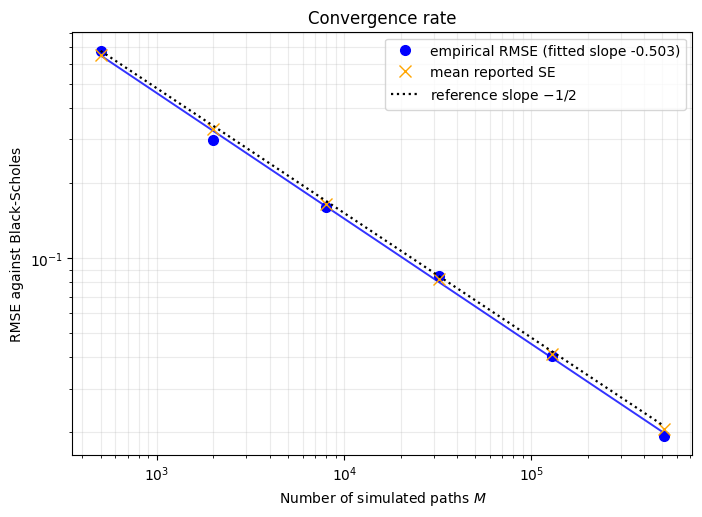

In [35]:
fig, ax = plt.subplots(figsize=(8, 5.5))

M_grid = study["n_paths"]
ax.loglog(M_grid, study["RMSE"], "o", ms=7, color="blue",
          label=f"empirical RMSE (fitted slope {slope:+.3f})")
ax.loglog(M_grid, const*M_grid**slope, "-", color="blue", lw=1.4, alpha=0.8)
ax.loglog(M_grid, study["mean_se"], "x", ms=8, color="orange",
          label="mean reported SE")
ax.loglog(M_grid, study["RMSE"][0]*(M_grid/M_grid[0])**-0.5, ":", color="black",
          lw=1.6, label="reference slope $-1/2$")

ax.set_xlabel("Number of simulated paths $M$")
ax.set_ylabel("RMSE against Black-Scholes")
ax.set_title("Convergence rate")
ax.legend()
ax.grid(alpha=0.25, which="both")
plt.show()

**Convergence summary.** The empirical convergence rate is $-0.50$ to two decimal places, matching the CLT prediction, and the fitted constant recovers the standard deviation of the discounted payoffs. Reported standard errors agree with the errors actually made at every path count, and no bias is detectable at any $M$ , consistent with the exact GBM solution.

## 4. Antithetic variates

The standard error of our previous estimator is $\hat{\sigma}_D/\sqrt{M}$. The $\sqrt{M}$ is due to the CLT so cannot be improved

That factor is not adjustable either. $\sigma_D$ is the standard deviation of the discounted payoff, determined entirely by the contract and the model. What variance reduction does is construct a different estimator $Y$ with $\mathbb{E}[Y] = C_0$ but $\mathrm{Var}(Y) < \mathrm{Var}(D)$. The only binding constraint is on the mean.

Antithetic sampling constructs such a $Y$ by pairing every draw $Z$ with its mirror image $-Z$:

$$Y_i = \tfrac{1}{2}\left(D(Z_i) + D(-Z_i)\right).$$

Since the standard normal is symmetric, $-Z$ is itself a valid $N(0,1)$ draw, so $\mathbb{E}[Y_i] = \mathbb{E}[D]$ and the estimator remains unbiased. The gain comes from the pair being negatively correlated: the call payoff is an increasing function of $Z$, so a draw giving a large payoff has a mirror giving a small one, and averaging the two cancels part of the noise.

### Variance of the pair average

Writing $\rho$ for the correlation between $D(Z)$ and $D(-Z)$:

$$\mathrm{Var}(Y_i) = \mathrm{Var}\!\left(\tfrac{1}{2}\left(D(Z_i)+D(-Z_i)\right)\right) = \frac{\sigma_D^2(1+\rho)}{2}.$$

At $\rho = -0.5$ this is $0.25\,\sigma_D^2$ — a quarter of a single payoff's variance, which looks like a $4\times$ gain. It is not, because $M$ payoff evaluations now produce only $M/2$ independent values of $Y$:

$$\mathrm{Var}\!\left(\hat{C}^{\text{anti}}\right) = \frac{\mathrm{Var}(Y)}{M/2} = \frac{\sigma_D^2(1+\rho)}{M}, \qquad \mathrm{Var}\!\left(\hat{C}^{\text{crude}}\right) = \frac{\sigma_D^2}{M}.$$

The variance reduction factor at equal cost is therefore

$$\frac{1}{1+\rho},$$

which is $2\times$ at $\rho=-0.5$, not $4\times$. Half of the apparent gain is given back by halving the number of independent samples.

### The standard error cannot use the pooled sample

The $M$ payoffs are correlated in pairs, not independent, so you must form the $M/2$ pairs first, and treat these as the i.i.d samples

$$\hat{C}^{\text{anti}} = \overline{Y}, \qquad \mathrm{SE} = \frac{\hat{\sigma}_Y}{\sqrt{M/2}}.$$

### Measuring the correlation

The variance reduction factor depends on $\rho = \mathrm{Corr}\big(D(Z),\,D(-Z)\big)$ — the correlation between the discounted payoffs obtained from a draw and from its mirror. This is a property of the contract and the model; it is measured, not chosen, and it varies with moneyness.

In [37]:
def antithetic_correlation(S0,K,T,r,sigma,n_pairs,rng,payoff_fn):
    Z = rng.standard_normal(n_pairs)
    ST_pos = S0*np.exp((r-0.5*sigma**2)*T + (sigma * np.sqrt(T)*Z))
    ST_neg = S0*np.exp((r-0.5*sigma**2)*T + (sigma * np.sqrt(T)*(-Z)))
    D_plus = np.exp(-r*T)*payoff_fn(ST_pos, K)
    D_minus = np.exp(-r*T)*payoff_fn(ST_neg ,K)
    rho = np.corrcoef(D_plus,D_minus)[0,1]
    return((D_plus,D_minus,rho))


### How does moneyness and payoff shape affect the VRF?
Antithetic variates exploit monotonicity in $Z$. The following sweep measures $\rho$ and the resulting VRF across a call at three strikes, a put, and a straddle.

In [38]:
data = [{
    "": "call, K=80 (ITM)", "rho": antithetic_correlation(S0, 80, T, r, sigma, 250000, rng, call_payoff)[2], "VRF": 1/(1+antithetic_correlation(S0, 80, T, r, sigma, 250000, rng, call_payoff)[2])},{
    "": "call, K=100 (ATM)", "rho": antithetic_correlation(S0, 100, T, r, sigma, 250000, rng, call_payoff)[2], "VRF": 1/(1+antithetic_correlation(S0, 100, T, r, sigma, 250000, rng, call_payoff)[2])},{
    "": "call, K=130 (OTM)", "rho": antithetic_correlation(S0, 130, T, r, sigma, 250000, rng, call_payoff)[2], "VRF": 1/(1+antithetic_correlation(S0, 130, T, r, sigma, 250000, rng, call_payoff)[2])},{
    "": "put, K=100 (ATM)", "rho": antithetic_correlation(S0, 100, T, r, sigma, 250000, rng, put_payoff)[2], "VRF": 1/(1+antithetic_correlation(S0, 100, T, r, sigma, 250000, rng, put_payoff)[2])},{
    "": "straddle, K=100 ", "rho": antithetic_correlation(S0, 100, T, r, sigma, 250000, rng, straddle_payoff)[2], "VRF": 1/(1+antithetic_correlation(S0, 100, T, r, sigma, 250000, rng, straddle_payoff)[2])
}]
df = pd.DataFrame(data)
print(df)

                           rho       VRF
0   call, K=80 (ITM) -0.884496  8.745174
1  call, K=100 (ATM) -0.500407  2.003941
2  call, K=130 (OTM) -0.070933  1.075696
3   put, K=100 (ATM) -0.414256  1.710658
4   straddle, K=100   0.644525  0.607784


VRF is largest deep in the money, where the payoff is nearly linear in $Z$ and mirrored draws are almost perfectly anti-correlated.
It is negligible far out of the money, where both members of a pair are usually zero and there is little to cancel. 
And it reverses for the straddle: the payoff $|S_T-K|$ is not monotone, so a large draw in either direction gives a large payoff,
 mirrored draws are positively correlated, and antithetic sampling increases variance rather than reducing it.


### The sampling distribution, simple vs antithetic


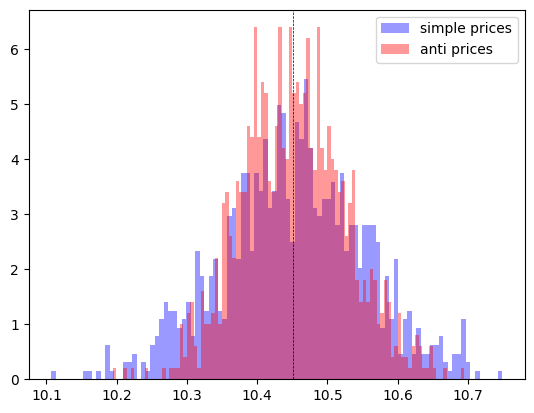

VRF:1.8704, simple_mean: 10.4521, anti_mean: 10.4517


In [ ]:
M = 20000

simple_prices = np.zeros(1000)
anti_prices = np.zeros(1000)
for i in range(1000):
    simple_prices[i]=mc_european_price(S0,K,T,r,sigma,M,rng,"call",False).price
    anti_prices[i]=mc_european_price(S0,K,T,r,sigma,M,rng,"call",True).price

plt.hist(simple_prices, bins = 100, alpha = 0.4, label = "simple prices", color = "blue", density=True)
plt.hist(anti_prices, bins = 100, alpha = 0.4, label = "anti prices", color = "red", density = True)
plt.axvline(black_scholes_price(S0,K,T,r,sigma), color = "black", lw = 0.5, linestyle = "--")
plt.legend()
plt.show()

print(f"VRF:{simple_prices.var(ddof=1)/anti_prices.var(ddof=1):.4f}, simple_mean: {simple_prices.mean():.4f}, anti_mean: {anti_prices.mean():.4f}")


### Summary
Antithetic variates gave a variance reduction of roughly 2× for the ATM call, matching the $1/(1+\rho)$ prediction from the measured correlation, and confirmed independently by the spread of 2,000 repeated price estimates. The benefit is not uniform: it is largest deep in the money, negligible far out of the money, and reverses for a straddle, whose non-monotone payoff makes mirrored draws positively correlated.

## 5. Limitations and extensions

### Model assumptions

**Constant volatility.** Real implied volatility varies by strike and maturity, which is direct evidence that the market does not price options as if $\sigma$ were constant. The model is used anyway, as a common quoting convention rather than a claim about reality: a price is often quoted as "the $\sigma$ that Black-Scholes would need to reproduce it," which is well-defined even though the model that produced the formula is known to be wrong.

**No jumps.** Prices are assumed to move continuously. A discrete jump — an earnings surprise, a central bank announcement — cannot be delta-hedged through, because the hedge ratio $\Delta$ was set for the price just before the jump and does not anticipate it.

**Continuous, costless rebalancing.** The replication argument underlying both the binomial model and the Black-Scholes PDE assumes the hedge can be adjusted continuously at zero cost. In practice rebalancing is discrete and each trade incurs a cost, so perfect replication is unavailable in principle, not merely in practice.

**Infinite liquidity.** Any quantity can be traded instantly at the quoted price.s.

**Constant, known parameters.** $r$ and $\sigma$ are treated as fixed and observable, rather than themselves uncertain or time-varying.

### Method limitations

**The $M^{-1/2}$ convergence rate is slow.** One additional decimal place of accuracy costs a 100 $\times$ increase in the number of simulated paths. 

**Antithetic variates help least where crude Monte Carlo struggles most.** The variance reduction measured in Section 4 was largest deep in the money and negligible far out of the money ($\rho \approx -0.07$ at $K=130$) — precisely the regime where the relative standard error is largest, because the payoff is concentrated in a small fraction of paths that finish in the money.



**Coverage at small $M$:** The 95% confidence intervals used throughout this notebook assume the price estimate is approximately normally distributed, a consequence of the Central Limit Theorem, which only applies once enough paths have been averaged together. For most options that happens quickly. But for a deep out-of-the-money option, the vast majority of simulated payoffs are exactly zero, with only a small fraction contributing anything nonzero therefore more simulated paths are required before the distribution of prices begins to look normal.
### Extensions

**Control variates.** More general than antithetic sampling: using a correlated quantity $X$ with a known expectation gives a variance reduction factor of $1/(1-\rho_{DX}^2)$, which works for correlation of either sign rather than only $\rho<0$. The natural application beyond this project is pricing an Asian option using the vanilla European call as a control, since the two payoffs are highly correlated and the European price is already known in closed form.

**Importance sampling.** The appropriate tool for the deep out-of-the-money regime where antithetic variates do nothing: sample from a distribution shifted to place more mass in the money, and correct for the change of measure by reweighting each payoff. Directly addresses the problem that most simulated paths currently contribute nothing.

**Path-dependent payoffs.** Our simulate_price function was built for this from the start. Asian options (payoff on the path average), barriers (monitored continuously or at discrete dates), and lookbacks (payoff on the running extremum) all require the full path rather than the terminal value alone, and none has a closed-form solution, this is the setting in which Monte Carlo stops being a demonstration against a known answer and becomes the only practical method.